***1.Uploading dataset and Importing Libraries***

In [ ]:
import chardet

with open('Global YouTube Statistics.csv', 'rb') as f:
    result = chardet.detect(f.read())

print(result)

{'encoding': 'ISO-8859-1', 'confidence': 0.7296382471623758, 'language': ''}


In [ ]:
import pandas as pd
df = pd.read_csv(
    'Global YouTube Statistics.csv',
    encoding='ISO-8859-1'
)

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score

***2.Data Understanding***

In [ ]:
#1st 5 Rows
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country of origin,Country,Abbreviation,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000.0,2.280000e+11,Music,T-Series,20082,India,india,IN,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000.0,0.000000e+00,Film & Animation,youtubemovies,1,United States,United States,US,...,NaN,2006.0,NaN,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000.0,2.836884e+10,Entertainment,MrBeast,741,United States,United States,US,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000.0,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,United States,US,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000.0,1.480000e+11,Shows,SET India,116536,India,India,IN,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [ ]:
# Shows rows and columns
df.shape

(1006, 29)

In [ ]:
# Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     1006 non-null   int64  
 1   Youtuber                                 1006 non-null   object 
 2   subscribers                              1003 non-null   float64
 3   video views                              1006 non-null   float64
 4   category                                 951 non-null    object 
 5   Title                                    1006 non-null   object 
 6   uploads                                  1006 non-null   int64  
 7   Country of origin                        881 non-null    object 
 8   Country                                  881 non-null    object 
 9   Abbreviation                             881 non-null    object 
 10  channel_type                             974 non

In [ ]:
# Statistical summary
df.describe()

,rank,subscribers,video views,uploads,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,...,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
count,1006.000000,1.003000e+03,1.006000e+03,1006.000000,1.005000e+03,887.000000,971.000000,9.490000e+02,1006.000000,1.006000e+03,...,1.006000e+03,6.660000e+02,1001.000000,1001.000000,880.000000,8.800000e+02,880.000000,8.800000e+02,880.000000,880.000000
mean,497.472167,2.319501e+07,1.112411e+10,9168.335984,5.607670e+05,384.289741,742.311020,1.760978e+08,37034.348489,5.922453e+05,...,7.110327e+06,3.495419e+05,2012.613387,15.712288,63.597273,4.304586e+08,9.258966,2.239747e+08,26.639994,-13.811287
std,288.738758,1.783047e+07,1.424148e+10,34028.189437,1.368886e+06,1227.359768,1938.126477,4.152933e+08,71869.653679,1.148967e+06,...,1.379921e+07,6.131554e+05,4.514131,8.765109,26.095537,4.735536e+08,4.889912,1.550381e+08,20.516025,84.728810
min,1.000000,1.230000e+07,0.000000e+00,0.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,0.000000,0.000000e+00,...,0.000000e+00,1.000000e+00,1970.000000,1.000000,7.600000,2.025060e+05,0.750000,3.558800e+04,-38.416097,-172.104629
25%,247.250000,1.450000e+07,4.281427e+09,194.000000,3.220000e+02,11.000000,26.000000,1.974000e+07,2700.000000,4.340000e+04,...,5.207500e+05,1.000000e+05,2009.000000,8.000000,36.300000,8.313280e+07,5.270000,5.590832e+07,20.593684,-95.712891
50%,498.500000,1.770000e+07,7.751292e+09,726.500000,9.190000e+02,50.000000,65.000000,6.408500e+07,13250.000000,2.117000e+05,...,2.550000e+06,2.000000e+05,2013.000000,16.000000,68.000000,3.282395e+08,8.880000,2.706630e+08,37.090240,-51.925280
75%,748.750000,2.475000e+07,1.357357e+10,2606.500000,3.645000e+03,123.000000,139.000000,1.692420e+08,38125.000000,6.101750e+05,...,7.300000e+06,4.000000e+05,2016.000000,23.000000,88.200000,3.282395e+08,14.700000,2.706630e+08,37.090240,78.962880
max,995.000000,2.450000e+08,2.280000e+11,301308.000000,4.057944e+06,7741.000000,7741.000000,6.589000e+09,850900.000000,1.360000e+07,...,1.634000e+08,8.000000e+06,2022.000000,31.000000,113.100000,1.397715e+09,14.720000,8.429340e+08,61.924110,138.252924


***3.Data Cleaning***

In [ ]:
# Missing Values
df.isnull().sum()

,0
rank,0
Youtuber,0
subscribers,3
video views,0
category,55
Title,0
uploads,0
Country of origin,125
Country,125
Abbreviation,125


In [ ]:
# Numerical Columns filling with median
num_cols=df.select_dtypes(include=np.number).columns

df[num_cols]=df[num_cols].fillna(df[num_cols].median())

In [ ]:
# Categorical Columns filling with "Unknown"
cat_cols=df.select_dtypes(include='object').columns

df[cat_cols]=df[cat_cols].fillna("Unknown")

In [ ]:
# Duplicates
df.drop_duplicates(inplace=True)

***4.Checking Dataset***

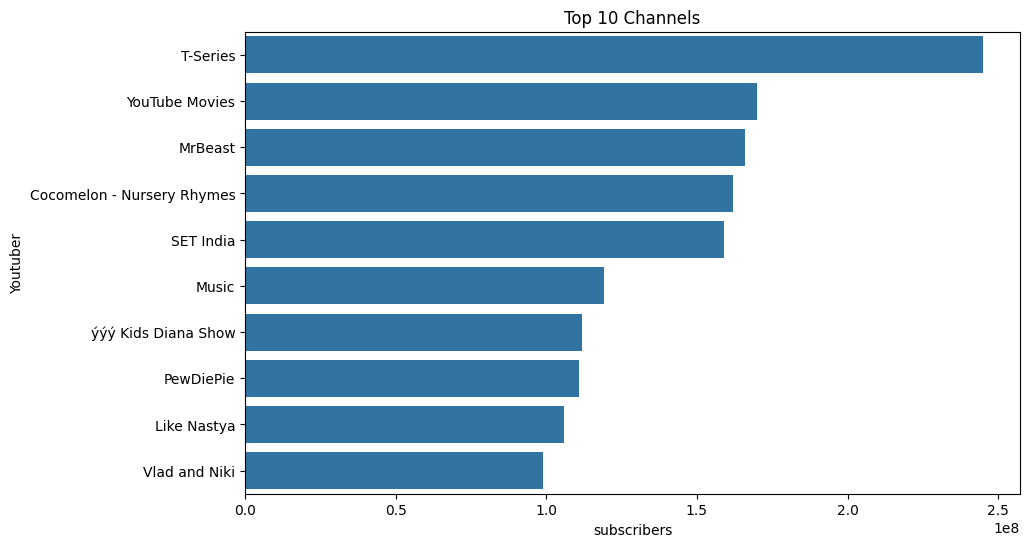

In [ ]:
# Q1.Top 10 Channels.
top10=df.nlargest(10,'subscribers')

plt.figure(figsize=(10,6))
sns.barplot(
data=top10,
x='subscribers',
y='Youtuber'
)
plt.title("Top 10 Channels")
plt.show()

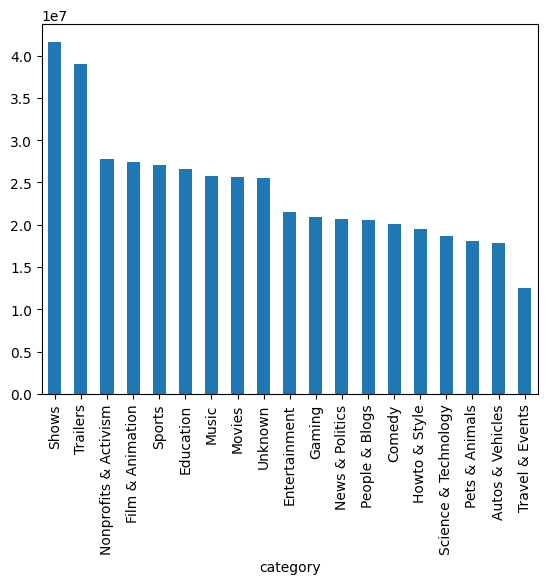

In [ ]:
# Q2.Highest Subscriber Category.
cat_sub=df.groupby('category')['subscribers'].mean().sort_values(ascending=False)

cat_sub.plot(kind='bar')
plt.show()

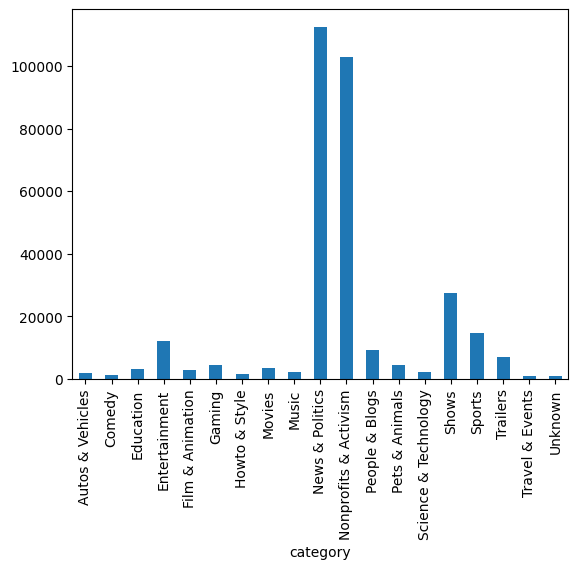

In [ ]:
# Q3. Average Uploads Per Category
uploads=df.groupby('category')['uploads'].mean()

uploads.plot(kind='bar')
plt.show()

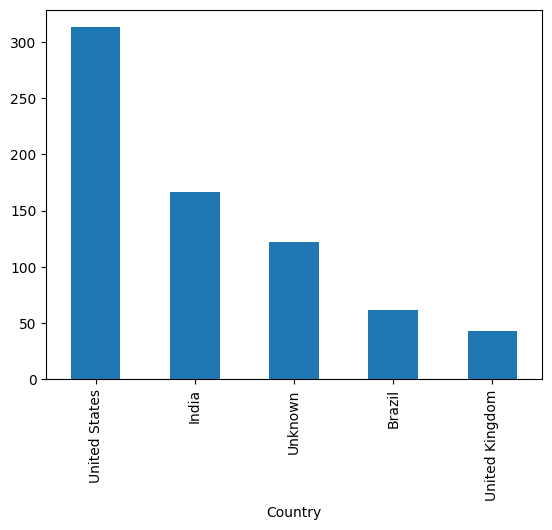

In [ ]:
# Q4. Top 5 Countries
country=df['Country'].value_counts().head(5)

country.plot(kind='bar')
plt.show()

<Axes: xlabel='channel_type', ylabel='category'>

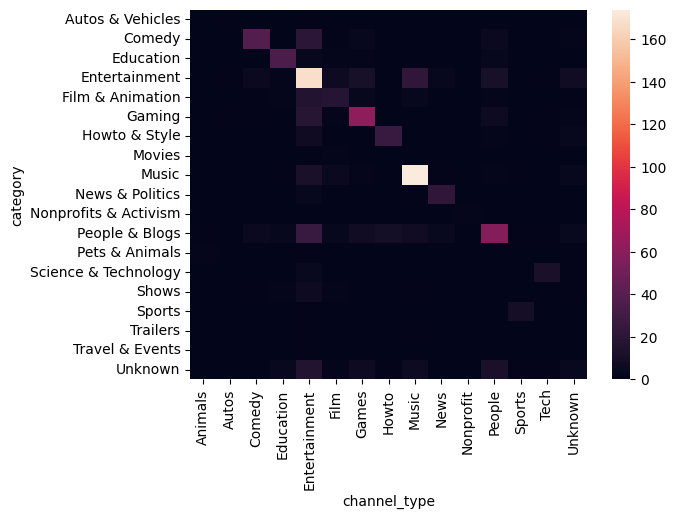

In [ ]:
# Q5. Channel Type Distribution
cross=pd.crosstab(
df['category'],
df['channel_type']
)

sns.heatmap(cross)

<Axes: xlabel='video views', ylabel='subscribers'>

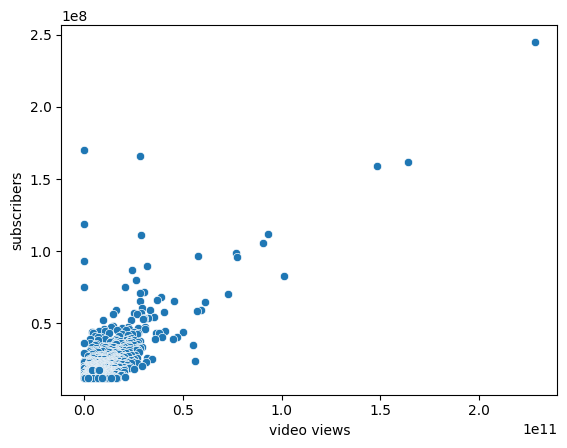

In [ ]:
# Q6. Subscribers vs Views
sns.scatterplot(
data=df,
x='video views',
y='subscribers'
)

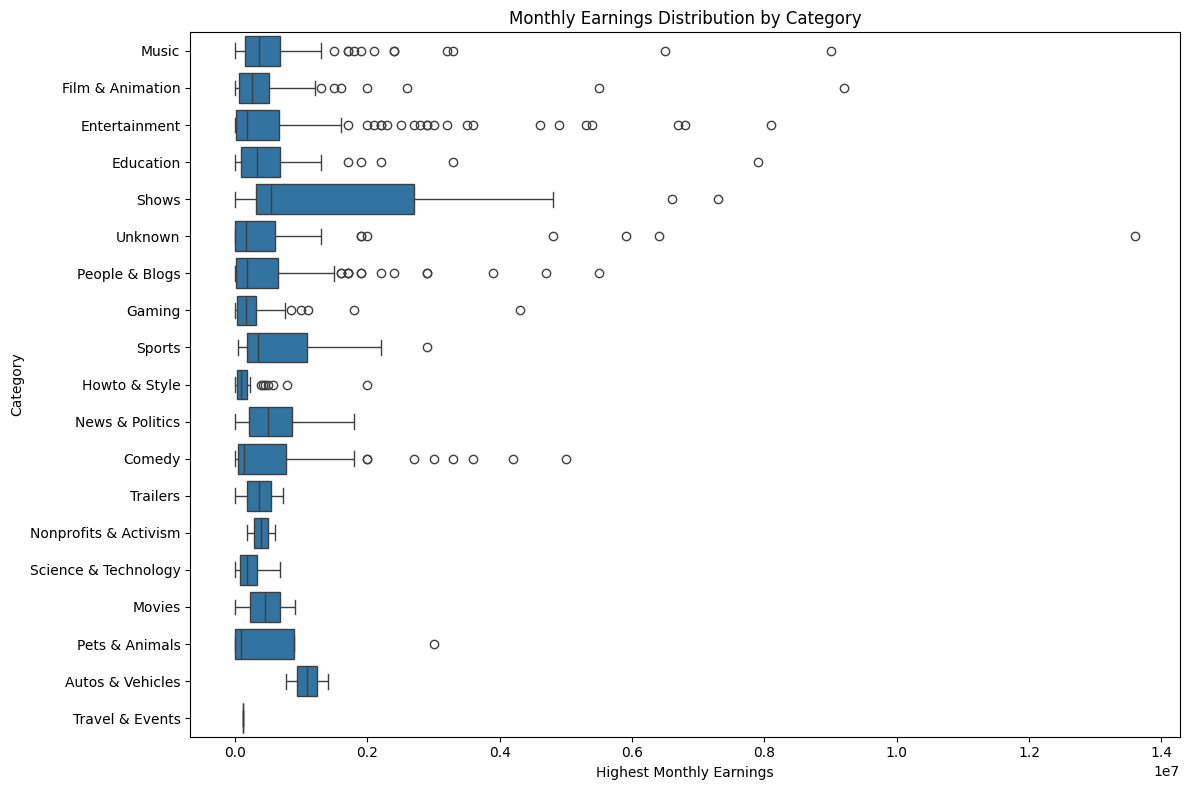

In [ ]:
# Q7. Earnings by Category
plt.figure(figsize=(12,8))

sns.boxplot(
    data=df,
    y='category',
    x='highest_monthly_earnings'
)

plt.title('Monthly Earnings Distribution by Category')
plt.xlabel('Highest Monthly Earnings')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

<Axes: xlabel='subscribers_for_last_30_days', ylabel='Count'>

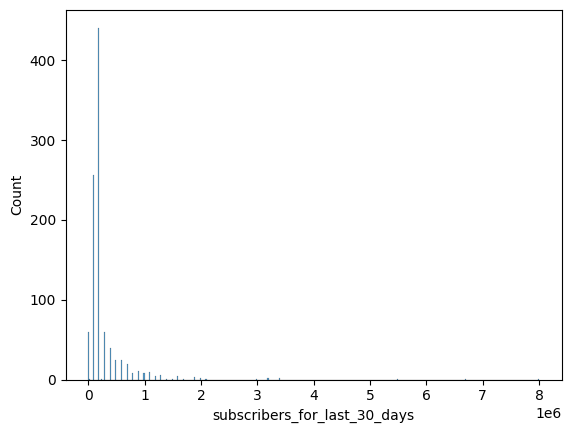

In [ ]:
# Q8. Subscriber Growth
sns.histplot(
df['subscribers_for_last_30_days']
)

<Axes: xlabel='highest_yearly_earnings'>

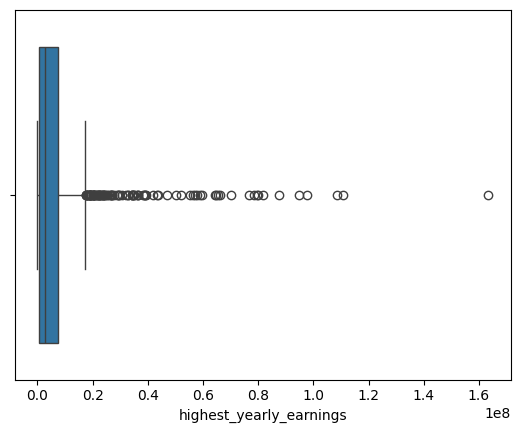

In [ ]:
# Q9. Earnings Outliers
sns.boxplot(
x=df['highest_yearly_earnings']
)

<Axes: xlabel='created_year'>

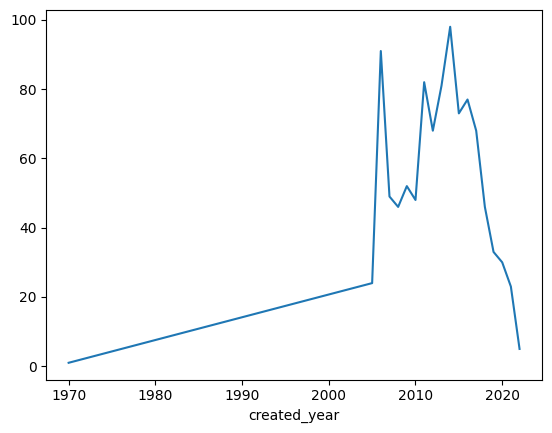

In [ ]:
# Q10. Channel Creation Trend
df['created_year'].value_counts().sort_index().plot()

Correlation: 0.123


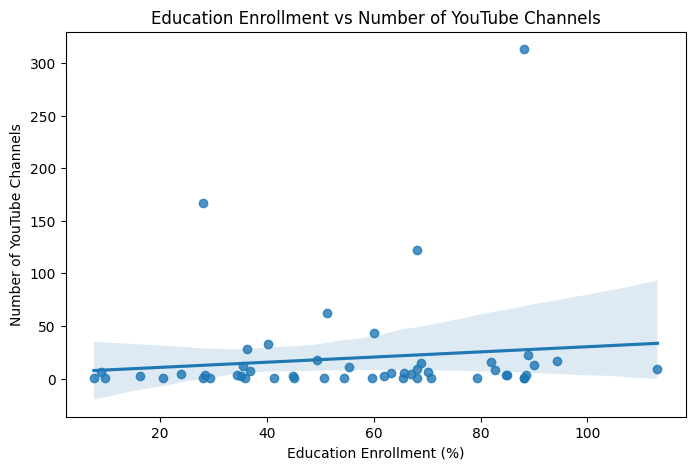

In [ ]:
# Q11: Education Enrollment vs Number of YouTube Channels

import matplotlib.pyplot as plt
import seaborn as sns

# Count channels in each country
country_channels = df.groupby('Country').size().reset_index(name='channel_count')

# Average education enrollment for each country
education = df.groupby('Country')['Gross tertiary education enrollment (%)'].mean().reset_index()

# Merge both tables
merged_df = pd.merge(country_channels, education, on='Country')

# Calculate correlation
corr = merged_df['channel_count'].corr(
    merged_df['Gross tertiary education enrollment (%)']
)

print("Correlation:", round(corr, 3))

# Scatter Plot
plt.figure(figsize=(8,5))

sns.regplot(
    data=merged_df,
    x='Gross tertiary education enrollment (%)',
    y='channel_count'
)

plt.title('Education Enrollment vs Number of YouTube Channels')
plt.xlabel('Education Enrollment (%)')
plt.ylabel('Number of YouTube Channels')

plt.show()

Country
Brazil            12.08
India              5.36
Indonesia          4.69
Mexico             3.42
South Korea        4.15
Spain             13.96
Thailand           0.75
United Kingdom     3.85
United States     14.70
Unknown            8.88
Name: Unemployment rate, dtype: float64


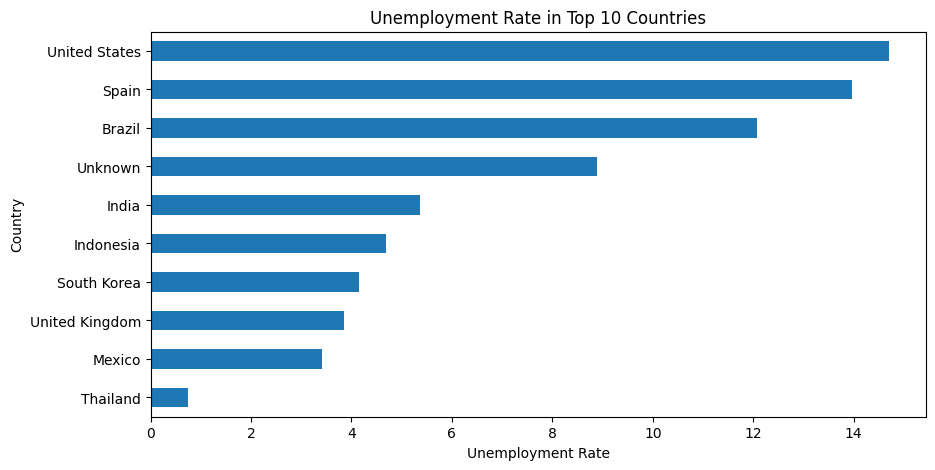

In [ ]:
# Q12. Unemployment Rate
# Find top 10 countries by channel count
top10 = df['Country'].value_counts().head(10).index

# Filter data
top_countries = df[df['Country'].isin(top10)]

# Average unemployment rate
unemployment = top_countries.groupby('Country')['Unemployment rate'].mean()

print(unemployment)

# Plot
plt.figure(figsize=(10,5))
unemployment.sort_values().plot(kind='barh')
plt.title('Unemployment Rate in Top 10 Countries')
plt.xlabel('Unemployment Rate')
plt.show()

Average Urban Population = 229956800.43


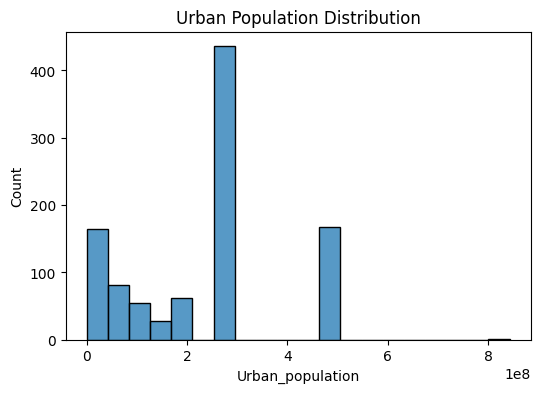

In [ ]:
# Q13. What is the average urban population percentage in countries with YouTube channels?
avg_urban = df['Urban_population'].mean()

print("Average Urban Population =", round(avg_urban,2))

plt.figure(figsize=(6,4))
sns.histplot(df['Urban_population'], bins=20)
plt.title('Urban Population Distribution')
plt.show()

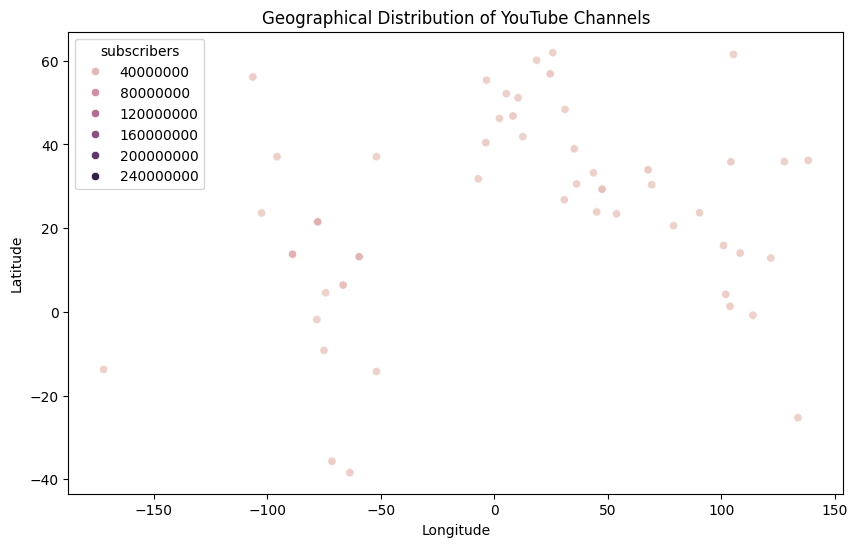

In [ ]:
# Q14. Are there any patterns in the distribution of YouTube channels based on latitude and longitude coordinates?
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Longitude',
    y='Latitude',
    hue='subscribers'
)

plt.title('Geographical Distribution of YouTube Channels')
plt.show()

Correlation = 0.077


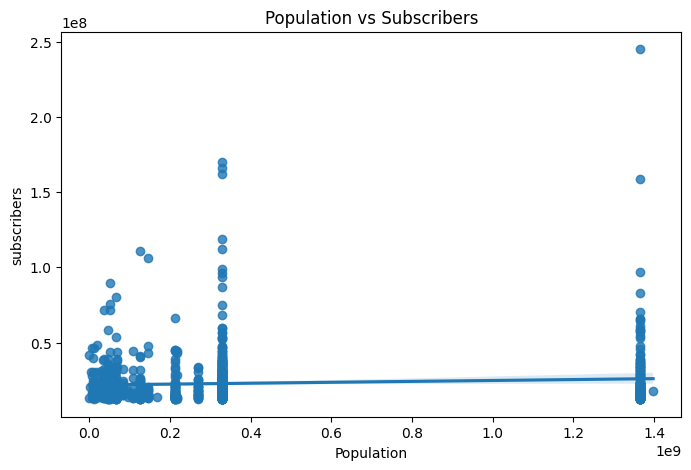

In [ ]:
# Q15. What is the correlation between the number of subscribers and the population of a country?
corr = df['subscribers'].corr(df['Population'])

print("Correlation =", round(corr,3))

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='Population',
    y='subscribers'
)

plt.title('Population vs Subscribers')
plt.show()

Country
Brazil            2.125594e+08
India             1.366418e+09
Indonesia         2.702039e+08
Mexico            1.260140e+08
South Korea       5.170910e+07
Spain             4.707678e+07
Thailand          6.962558e+07
United Kingdom    6.683440e+07
United States     3.282395e+08
Unknown           3.282395e+08
Name: Population, dtype: float64


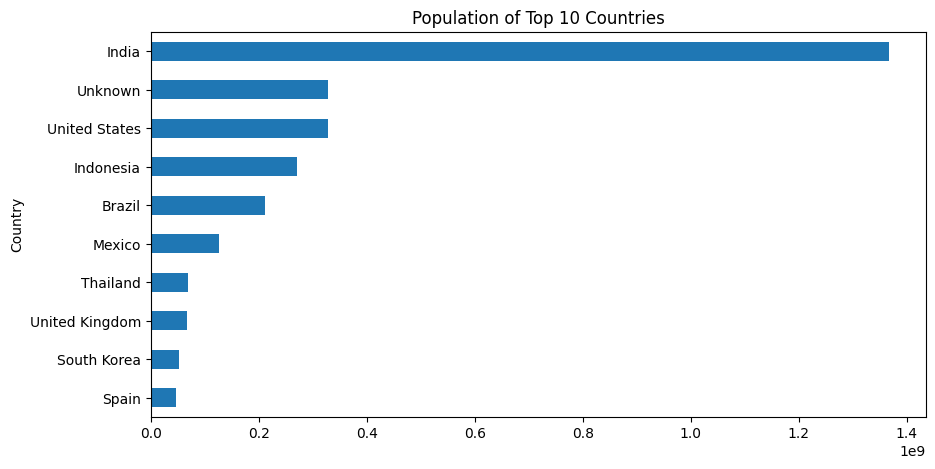

In [ ]:
# Q16. How do the top 10 countries compare in terms of their total population?
top10 = df['Country'].value_counts().head(10).index

temp = df[df['Country'].isin(top10)]

population = temp.groupby('Country')['Population'].mean()

print(population)

plt.figure(figsize=(10,5))
population.sort_values().plot(kind='barh')
plt.title('Population of Top 10 Countries')
plt.show()

Correlation = -0.029


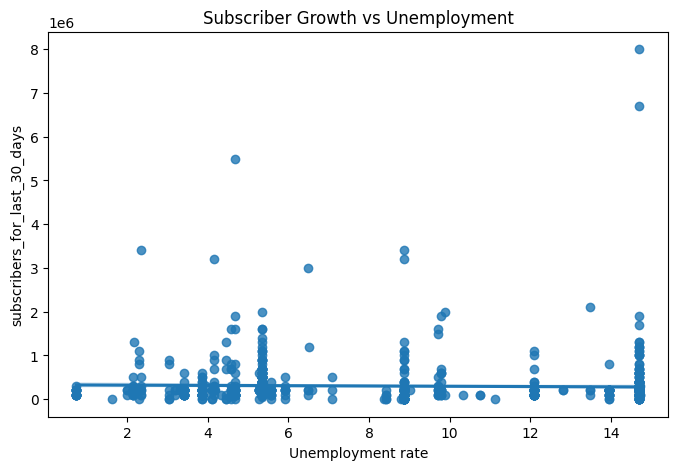

In [ ]:
# Q17. Is there a correlation between subscribers gained in the last 30 days and unemployment rate?
corr = df['subscribers_for_last_30_days'].corr(
    df['Unemployment rate']
)

print("Correlation =", round(corr,3))

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='Unemployment rate',
    y='subscribers_for_last_30_days'
)

plt.title('Subscriber Growth vs Unemployment')
plt.show()

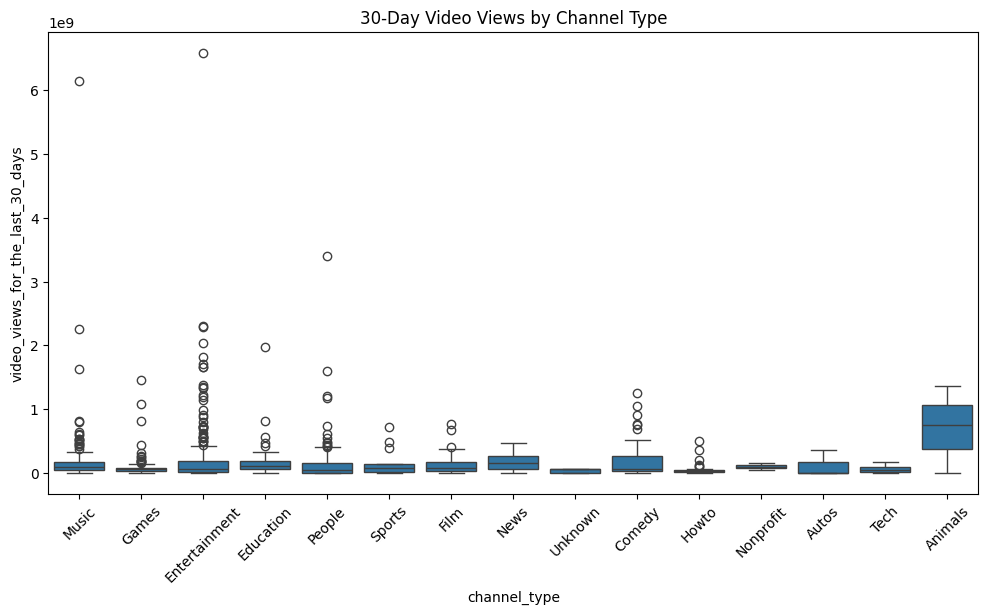

In [ ]:
# Q18. How does the distribution of video views for the last 30 days vary across different channel types?
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='channel_type',
    y='video_views_for_the_last_30_days'
)

plt.xticks(rotation=45)

plt.title(
    '30-Day Video Views by Channel Type'
)

plt.show()

created_month
Apr         2499.929577
Aug        16280.185185
Dec         3678.666667
Feb        11732.582090
Jan         8023.560000
Jul         5603.808989
Jun        13409.191781
Mar         4339.232558
May         7835.880952
Nov         8939.700000
Oct        16885.896104
Sep        12300.104167
Unknown      678.166667
Name: uploads, dtype: float64


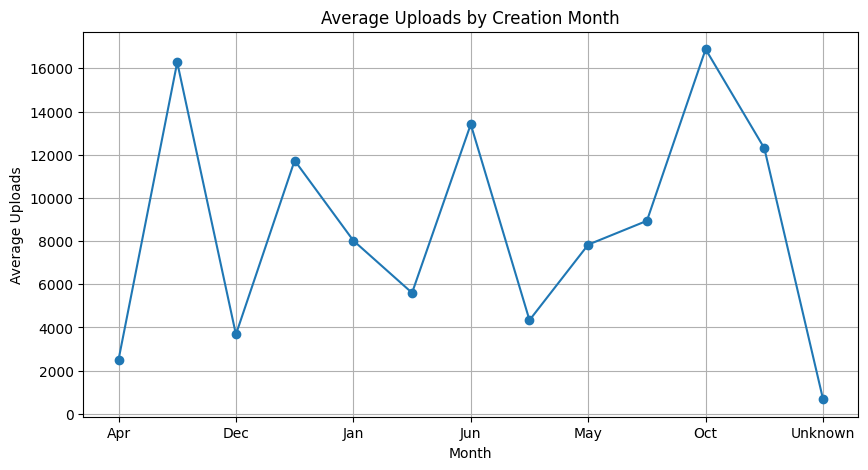

In [ ]:
# Q19. Are there any seasonal trends in the number of videos uploaded by YouTube channels?

import matplotlib.pyplot as plt

# Average uploads by creation month
uploads_month = df.groupby('created_month')['uploads'].mean()

print(uploads_month)

# Plot
plt.figure(figsize=(10,5))

uploads_month.plot(
    kind='line',
    marker='o'
)

plt.title('Average Uploads by Creation Month')
plt.xlabel('Month')
plt.ylabel('Average Uploads')

plt.grid(True)

plt.show()

                     Youtuber  avg_subscribers_per_month
0                    T-Series               1.020833e+06
1              YouTube Movies               7.083333e+05
2                     MrBeast               9.880952e+05
3  Cocomelon - Nursery Rhymes               6.750000e+05
4                   SET India               6.625000e+05


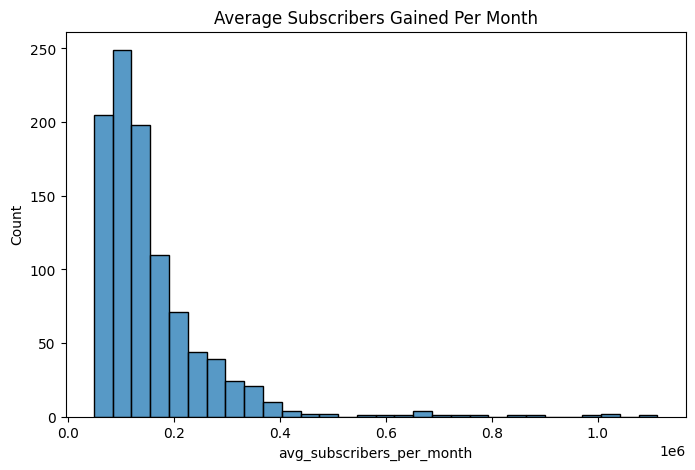

In [ ]:
# Q20. What is the average number of subscribers gained per month since the creation of YouTube channels till now?
from datetime import datetime

current_year = datetime.now().year

# Channel age in months
df['channel_age_months'] = ((current_year - df['created_year']) * 12)

# Avoid division by zero
df['channel_age_months'] = df['channel_age_months'].replace(0,1)

# Average subscribers gained per month
df['avg_subscribers_per_month'] = (
    df['subscribers']/df['channel_age_months'])

print(df[['Youtuber','avg_subscribers_per_month']].head())

plt.figure(figsize=(8,5))

sns.histplot(df['avg_subscribers_per_month'],bins=30)

plt.title('Average Subscribers Gained Per Month')
plt.show()

***5.Unique Features***

In [ ]:
# 1.Growth Score
df['Growth_Score']=(
df['subscribers_for_last_30_days']
/
df['subscribers']
)

df.nlargest(10,'Growth_Score')

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country of origin,Country,Abbreviation,...,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude,channel_age_months,avg_subscribers_per_month,Growth_Score
417,418,DaFuq!?Boom!,19600000.0,7.906182e+09,Film & Animation,DaFuq!?Boom!,214,United States,United States,US,...,6.0,88.2,328239523.0,14.70,270663028.0,37.090240,-95.712891,120.0,163333.333333,0.341837
483,484,BeatboxJCOP,18000000.0,8.716982e+09,Film & Animation,BeatboxJCOP,748,Unknown,Unknown,Unknown,...,12.0,68.0,328239523.0,8.88,270663028.0,37.090240,-51.925280,180.0,100000.000000,0.188889
598,599,Panda Shorts,16100000.0,7.155736e+09,Unknown,Panda Shorts,667,Sweden,Sweden,SE,...,21.0,67.0,10285453.0,6.48,9021165.0,60.128161,18.643501,72.0,223611.111111,0.186335
495,496,ýýýýýýýýý KIMPRO,17700000.0,1.920670e+10,Unknown,ýýýýýýýýý KIMPRO,1646,South Korea,South Korea,KR,...,11.0,94.3,51709098.0,4.15,42106719.0,35.907757,127.766922,108.0,163888.888889,0.180791
117,118,Jess No Limit,34000000.0,3.963007e+09,Entertainment,Jess No Limit,2284,Indonesia,Indonesia,ID,...,7.0,36.3,270203917.0,4.69,151509724.0,-0.789275,113.921327,108.0,314814.814815,0.161765
332,333,ZAMZAM ELECTRONICS TRADING,21700000.0,8.507819e+09,Unknown,ZAMZAM ELECTRONICS TRADING,15126,United Arab Emirates,United Arab Emirates,AE,...,19.0,36.8,9770529.0,2.35,8479744.0,23.424076,53.847818,72.0,301388.888889,0.156682
302,303,KL BRO Biju Rithvik,22800000.0,1.798835e+10,Entertainment,KL BRO Biju Rithvik,1841,Unknown,Unknown,Unknown,...,21.0,68.0,328239523.0,8.88,270663028.0,37.090240,-51.925280,72.0,316666.666667,0.140351
942,943,Go Ami Go!,12700000.0,1.714955e+09,People & Blogs,Go Ami Go!,252,Colombia,Colombia,CO,...,3.0,55.3,50339443.0,9.71,40827302.0,4.570868,-74.297333,132.0,96212.121212,0.118110
712,713,Filaretiki,14800000.0,1.578821e+10,Unknown,Filaretiki,2222,United States,United States,US,...,24.0,88.2,328239523.0,14.70,270663028.0,37.090240,-95.712891,60.0,246666.666667,0.114865
970,971,_vector_,12400000.0,7.597013e+09,Comedy,_vector_,398,United States,United States,US,...,24.0,88.2,328239523.0,14.70,270663028.0,37.090240,-95.712891,84.0,147619.047619,0.096774


In [ ]:
# 2.Revenue Efficiency (whcih channels earn more money per view.)
df['Revenue_Efficiency']=(
df['highest_yearly_earnings']/
df['video views'])

In [ ]:
# 3.Creator Succes Index
scaler=MinMaxScaler()  #normalize 1st

df[['sub_norm']]=scaler.fit_transform(df[['subscribers']])

df[['view_norm']]=scaler.fit_transform(df[['video views']])

df[['growth_norm']]=scaler.fit_transform(df[['Growth_Score']])

df[['earn_norm']]=scaler.fit_transform(df[['highest_yearly_earnings']])

#Creating CSI
df['CSI']=(
0.4*df['sub_norm']
+
0.3*df['view_norm']
+
0.2*df['growth_norm']
+
0.1*df['earn_norm']
)

#Top Creators
df.nlargest(10,'CSI')

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country of origin,Country,Abbreviation,...,Longitude,channel_age_months,avg_subscribers_per_month,Growth_Score,Revenue_Efficiency,sub_norm,view_norm,growth_norm,earn_norm,CSI
0,1,T-Series,245000000.0,2.280000e+11,Music,T-Series,20082,India,india,IN,...,78.962880,240.0,1.020833e+06,0.008163,0.000475,1.000000,1.000000,0.023881,6.634027e-01,0.771116
3,4,Cocomelon - Nursery Rhymes,162000000.0,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,United States,US,...,-95.712891,240.0,6.750000e+05,0.006173,0.000578,0.643318,0.719298,0.018058,5.801714e-01,0.534745
4,5,SET India,159000000.0,1.480000e+11,Shows,SET India,116536,India,India,IN,...,78.962880,240.0,6.625000e+05,0.006289,0.000591,0.630425,0.649123,0.018399,5.354957e-01,0.504136
2,3,MrBeast,166000000.0,2.836884e+10,Entertainment,MrBeast,741,United States,United States,US,...,-95.712891,168.0,9.880952e+05,0.048193,0.002281,0.660507,0.124425,0.140982,3.959608e-01,0.369323
6,7,ýýý Kids Diana Show,112000000.0,9.324704e+10,People & Blogs,ýýý Kids Diana Show,1111,United States,United States,US,...,-95.712891,132.0,8.484848e+05,0.001786,0.000376,0.428449,0.408978,0.005224,2.148103e-01,0.316599
15,16,Sony SAB,83000000.0,1.010000e+11,Shows,Sony SAB,71270,India,India,IN,...,78.962880,228.0,3.640351e+05,0.013253,0.000788,0.303825,0.442982,0.038770,4.871481e-01,0.310893
417,418,DaFuq!?Boom!,19600000.0,7.906182e+09,Film & Animation,DaFuq!?Boom!,214,United States,United States,US,...,-95.712891,120.0,1.633333e+05,0.341837,0.013989,0.031371,0.034676,1.000000,6.768666e-01,0.290638
8,9,Like Nastya,106000000.0,9.047906e+10,People & Blogs,Like Nastya Vlog,493,Russia,Russia,RU,...,105.318756,120.0,8.833333e+05,0.000943,0.000025,0.402664,0.396838,0.002760,1.407589e-02,0.282077
1,2,YouTube Movies,170000000.0,0.000000e+00,Film & Animation,youtubemovies,1,United States,United States,US,...,-95.712891,240.0,7.083333e+05,0.001176,inf,0.677697,0.000000,0.003442,3.549572e-09,0.271767
9,10,Vlad and Niki,98900000.0,7.718017e+10,Entertainment,Vlad and Niki,574,United States,United States,US,...,-95.712891,96.0,1.030208e+06,0.006067,0.000361,0.372153,0.338510,0.017747,1.707466e-01,0.271038


***6.Machine Learning - Random Forest Regression Model***


In [ ]:
#features
X=df[[
'subscribers',
'video views',
'uploads']
]

#Target
y=df['highest_yearly_earnings']


In [ ]:
#Spliting Data
X_train,X_test,y_train,y_test=train_test_split(
X,y,
test_size=0.2,
random_state=42
)

In [ ]:
#Training Model
model=RandomForestRegressor(
n_estimators=100,
random_state=42
)

model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [ ]:
#Predict
pred=model.predict(X_test)

In [ ]:
#Evaluate
print("MAE is:",mean_absolute_error(y_test,pred))

print("R2 Score is:",r2_score(y_test,pred))

MAE is: 5786003.497152764
R2 Score is: 0.30456132808061365


In [ ]:
#Feature Importance
importance=pd.DataFrame({
'Feature':X.columns,
'Importance':model.feature_importances_
})

print(
importance.sort_values(
'Importance',
ascending=False
)
)

       Feature  Importance
1  video views    0.540942
2      uploads    0.289730
0  subscribers    0.169328


***7.Save Processed Dataset***

In [ ]:
df.to_csv('Processed_YouTube.csv',index=False)

In [ ]:
import os

print(os.path.exists('Processed_YouTube.csv'))

True


In [ ]:
!ls

'Global YouTube Statistics.csv'   Processed_YouTube.csv   sample_data


In [ ]:
from google.colab import files

files.download('Processed_YouTube.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>